# Training Data Models on Processed Collections

This notebook trains 3610 models for each collection in `processed_collections`:
- Binary collections: **em_collection**, **f1_binary_collection**, **rougel_binary_collection** → Logistic Regression
- Continuous collections: **f1_collection**, **rougel_collection** → Linear Regression

Models are trained with different features and saved weights as tensors.

In [1]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import gc
import torch
import os
import json
from pathlib import Path
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import roc_auc_score, mean_absolute_error
from tqdm import tqdm
from numpy import float64
from utils.set_random_seed import set_random_seed

# Set random seed for reproducibility
set_random_seed(42)

# Configuration
BASE_PATH = Path(".")
COLLECTION_FOLDERS = ["llama", "llama_default", "qwen", "qwen_default"]  # Folders to process sequentially

# Define collections: binary vs continuous
# em_collection is binary, f1 and rougel can be either
BINARY_COLLECTIONS = ["em_collection", "f1_binary_collection", "rougel_binary_collection"]
CONTINUOUS_COLLECTIONS = ["f1_collection", "rougel_collection"]
ALL_COLLECTIONS = BINARY_COLLECTIONS + CONTINUOUS_COLLECTIONS


print(f"Collections to process: {COLLECTION_FOLDERS}")
print(f"Binary collections: {BINARY_COLLECTIONS}")
print(f"Continuous collections: {CONTINUOUS_COLLECTIONS}")
print(f"Total collections per folder: {len(ALL_COLLECTIONS)}")

# Storage for results from all folders
all_results_by_folder = {}  # Keys: folder names, Values: results dict

Collections to process: ['llama', 'llama_default', 'qwen', 'qwen_default']
Binary collections: ['em_collection', 'f1_binary_collection', 'rougel_binary_collection']
Continuous collections: ['f1_collection', 'rougel_collection']
Total collections per folder: 5


## Utility Functions

All helper functions for loading data, training models, saving weights, and evaluation.

**Organized into 5 subsections:**
1. **Data Loading** - Load feather files from processed_collections
2. **Model Training** - Train 3,610 models per collection (LogisticRegression or LinearRegression)
3. **Saving Weights** - Persist weights/biases as PyTorch tensors
4. **Evaluation** - Compute performance statistics (mean, std, min, max)
5. **Visualization** - Plot performance distributions for each folder

In [2]:
# ============ DATA LOADING ============

def load_collection_data(collection_name, processed_collections_path, split="train"):
    """Load a collection's data from feather files."""
    file_path = processed_collections_path / collection_name / f"{split}.feather"
    if not file_path.exists():
        print(f"Warning: {file_path} not found")
        return None
    return pl.read_ipc(str(file_path))

def load_collections_for_folder(folder_name, base_path=BASE_PATH):
    """Load all collections from a specific folder."""
    processed_collections_path = base_path / "processed_collections" / folder_name
    
    if not processed_collections_path.exists():
        print(f"Error: {processed_collections_path} does not exist")
        return None
    
    print(f"\n{'='*60}\nLoading collections from: {folder_name}\n{'='*60}")
    
    collections_data = {}
    for collection in ALL_COLLECTIONS:
        print(f"\nLoading {collection}...")
        if collection in [p.name for p in processed_collections_path.iterdir() if p.is_dir()]:
            train_df = load_collection_data(collection, processed_collections_path, "train")
            test_df = load_collection_data(collection, processed_collections_path, "test")
            
            if train_df is not None and test_df is not None:
                if "test_idx" in train_df.columns and "collection_idx" in train_df.columns:
                    train_df = train_df.sort("test_idx", "collection_idx")
                    test_df = test_df.sort("test_idx", "collection_idx")
                
                collections_data[collection] = {
                    "train": train_df,
                    "test": test_df,
                    "is_binary": collection in BINARY_COLLECTIONS
                }
                print(f"  Train shape: {train_df.shape}, Test shape: {test_df.shape}")
            else:
                print(f"  Failed to load {collection}")
    
    return collections_data

### Data Loading Functions

**Purpose**: Load feather files from processed_collections directories.

| Function | Input | Output | Description |
|----------|-------|--------|-------------|
| `load_collection_data()` | collection_name, path, split ("train"/"test") | Polars DataFrame or None | Loads a single collection's data from feather file. Returns None if file not found. |
| `load_collections_for_folder()` | folder_name, base_path | dict of DataFrames | Loads all 5 collections (binary + continuous) from a folder, sorts by indices, returns dictionary with train/test splits. |

In [3]:
# ============ MODEL TRAINING ============

def load_best_params(collection_name, collection_folder, processed_collections_path):
    """Load best hyperparameters from gridsearch JSON files."""
    params_file = processed_collections_path.parent / "hyperparameter_tuning" / "llama" /f"best_params_gridsearch_{collection_name}.json"
    
    if not params_file.exists():
        return None
    
    with open(params_file, "r") as f:
        data = json.load(f)
    
    best_params_list = [result.get("best_params") for result in data["results"]]
    return best_params_list

def prepare_data_splits(df, num_models=3610):
    """Prepare stratified data splits for training multiple models."""
    X_splits, y_splits = [], []
    
    for i in range(num_models):
        X = df.filter(pl.col("test_idx") == i).select("input").to_numpy()
        X = np.array([row[0] for row in X])
        y = df.filter(pl.col("test_idx") == i).select("evaluation").to_numpy()
        
        X_splits.append(X)
        y_splits.append(y)
    
    return X_splits, y_splits

def train_collection_models(collection_name, collection_folder, collections_data, processed_collections_path, num_models=3610):
    """Train all models for a specific collection."""
    if collection_name not in collections_data.keys():
        print(f"Collection {collection_name} not loaded")
        return None
    
    is_binary = collections_data[collection_name]["is_binary"]
    train_df = collections_data[collection_name]["train"]
    test_df = collections_data[collection_name]["test"]
    
    print(f"\n{'='*60}\nTraining {num_models} models for {collection_name} ({'Binary' if is_binary else 'Regression'})\n{'='*60}")
    
    best_params_list = load_best_params(collection_name, collection_folder, processed_collections_path) if is_binary else None
    X_train, y_train = prepare_data_splits(train_df, num_models)
    X_test, y_test = prepare_data_splits(test_df, num_models)
    
    models, evaluations, count_errors = [], [], 0
    
    with tqdm(total=num_models, desc=f"Training {collection_name}") as pbar:
        for i in range(num_models):
            model = None
            
            if is_binary:
                if best_params_list and i < len(best_params_list) and best_params_list[i]:
                    params = best_params_list[i].copy()
                    if params.get("solver") in ["lbfgs", "newton-cg"]:
                        params.pop("l1_ratio", None)
                    model = LogisticRegression(random_state=42, n_jobs=-1, **params)
                else:
                    model = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs', n_jobs=-1)
            else:
                model = LinearRegression(n_jobs=-1)
            
            try:
                model.fit(X_train[i], y_train[i].ravel())
            except Exception:
                model = None
                count_errors += 1
            
            if model is not None:
                try:
                    if is_binary:
                        y_pred_proba = model.predict_proba(X_test[i])[:, 1]
                        score = roc_auc_score(y_test[i].ravel(), y_pred_proba)
                        eval_metric = "auc"
                    else:
                        y_pred = model.predict(X_test[i])
                        score = mean_absolute_error(y_test[i].ravel(), y_pred)
                        eval_metric = "mae"
                    
                    evaluations.append({
                        "model_idx": i, "score": score, "metric": eval_metric,
                        "n_features": X_train[i].shape[1],
                        "n_train_samples": len(X_train[i]),
                        "n_test_samples": len(X_test[i])
                    })
                except Exception:
                    evaluations.append({
                        "model_idx": i, "score": None, "metric": "failed",
                        "n_features": X_train[i].shape[1],
                        "n_train_samples": len(X_train[i]),
                        "n_test_samples": len(X_test[i])
                    })
            else:
                evaluations.append({
                    "model_idx": i, "score": None, "metric": "failed",
                    "n_features": X_train[i].shape[1],
                    "n_train_samples": len(X_train[i]),
                    "n_test_samples": len(X_test[i])
                })
            
            models.append(model)
            pbar.update(1)
    
    print(f"  Total errors: {count_errors}/{num_models}")
    return {
        "models": models, "evaluations": evaluations, "is_binary": is_binary,
        "collection_name": collection_name, "num_models": num_models
    }

def train_all_collections_in_folder(folder_name, collections_data, num_models=3610):
    """Train models for all collections in a folder."""
    processed_collections_path = BASE_PATH / "processed_collections" / folder_name
    trained_models = {}
    import warnings
    warnings.filterwarnings('ignore')
    
    for collection in ALL_COLLECTIONS:
        result = train_collection_models(collection, folder_name, collections_data, processed_collections_path, num_models)
        if result is not None:
            trained_models[collection] = result
        gc.collect()
    
    return trained_models

### Model Training Functions

**Purpose**: Train 3,610 models per collection using LogisticRegression (binary) or LinearRegression (continuous).

| Function | Input | Output | Description |
|----------|-------|--------|-------------|
| `load_best_params()` | collection_name, path | list of dicts or None | Loads gridsearch best hyperparameters from JSON. Returns None if file missing. |
| `prepare_data_splits()` | DataFrame, num_models | tuple of lists | Splits data by test_idx into num_models separate X,y train/test pairs. |
| `train_collection_models()` | collection_name, data dict, path, num_models | dict with models & evaluations | Trains num_models (3610 default) for one collection. Evaluates with AUC (binary) or MAE (regression). Catches training/eval errors. |
| `train_all_collections_in_folder()` | folder_name, data dict, path, num_models | dict of all trained models | Iterates through ALL_COLLECTIONS and trains each one, returns consolidated results. |

In [4]:
# ============ SAVING WEIGHTS ============

def save_model_weights(training_results, folder_name, base_path=BASE_PATH):
    """Save model weights and biases as PyTorch tensors to both weights/ and runs/ paths."""
    collection_name = training_results["collection_name"]
    models = training_results["models"]
    is_binary = training_results["is_binary"]
    num_models = training_results["num_models"]
    
    # Extract weights and biases
    weights_list, bias_list = [], []
    
    for model in models:
        if model is not None:
            if is_binary:
                weights_list.append(model.coef_[0])
                bias_list.append(float(model.intercept_))
            else:
                weights_list.append(model.coef_)
                bias_list.append(float(model.intercept_))
        else:
            weights_list.append(np.concatenate([np.ones(16), np.zeros(84)]))
            bias_list.append(0.0)
    
    weights_tensor = torch.tensor(weights_list, dtype=torch.float32)
    bias_tensor = torch.tensor(bias_list, dtype=torch.float32)
    
    # Save to weights/ folder (original path)
    output_dir_pt = base_path / "weights" / folder_name / collection_name
    output_dir_pt.mkdir(parents=True, exist_ok=True)
    
    torch.save(weights_tensor, str(output_dir_pt / "weights.pt"))
    torch.save(bias_tensor, str(output_dir_pt / "bias.pt"))
    
    # Save to runs/ folder (new path with num_models in filename)
    output_dir_runs = base_path / "runs" / folder_name / "datamodels" / "models" / collection_name
    output_dir_runs.mkdir(parents=True, exist_ok=True)
    
    weights_file_runs = output_dir_runs / f"0_{num_models-1}_weights.pt"
    bias_file_runs = output_dir_runs / f"0_{num_models-1}_bias.pt"
    
    torch.save(weights_tensor, str(weights_file_runs))
    torch.save(bias_tensor, str(bias_file_runs))
    
    print(f"\n  Saving {collection_name}: weights {weights_tensor.shape}, bias {bias_tensor.shape}")
    print(f"    Saved to: {output_dir_pt}")
    print(f"    Saved to: {output_dir_runs}")
    
    return {
        "weights_file_pt": str(output_dir_pt / "weights.pt"),
        "bias_file_pt": str(output_dir_pt / "bias.pt"),
        "weights_file_runs": str(weights_file_runs),
        "bias_file_runs": str(bias_file_runs),
        "weights_shape": weights_tensor.shape,
        "bias_shape": bias_tensor.shape
    }

def save_all_weights_for_folder(folder_name, trained_models, base_path=BASE_PATH):
    """Save weights for all collections in a folder."""
    return {collection_name: save_model_weights(training_results, folder_name, base_path)
            for collection_name, training_results in trained_models.items()}

### Saving Weights Functions

**Purpose**: Persist trained model weights and biases as PyTorch tensors to disk.

| Function | Input | Output | Description |
|----------|-------|--------|-------------|
| `save_model_weights()` | training_results dict, folder_name, base_path | dict with file paths & shapes | Extracts coef_ and intercept_ from trained models, converts to PyTorch tensors, saves weights.pt and bias.pt. Handles None models with fallback zeros. |
| `save_all_weights_for_folder()` | folder_name, trained_models dict, base_path | dict of save results | Calls save_model_weights() for each collection, returns consolidated results. |

In [5]:
# ============ EVALUATION ============

def create_evaluation_summary(training_results, folder_name):
    """Create evaluation summary for a collection."""
    collection_name = training_results["collection_name"]
    is_binary = training_results["is_binary"]
    evaluations = training_results["evaluations"]
    
    eval_df = pl.DataFrame(evaluations)
    valid_scores = eval_df.filter(pl.col("score").is_not_null() & pl.col("score").is_not_nan())
    
    if len(valid_scores) > 0:
        return {
            "folder": folder_name, "collection": collection_name,
            "type": "Binary Classification" if is_binary else "Regression",
            "metric": eval_df[0]["metric"],
            "num_models": len(evaluations),
            "successful_models": len(valid_scores),
            "mean_score": valid_scores.select(pl.col("score").mean())[0, 0],
            "std_score": valid_scores.select(pl.col("score").std())[0, 0],
            "min_score": valid_scores.select(pl.col("score").min())[0, 0],
            "max_score": valid_scores.select(pl.col("score").max())[0, 0],
        }
    else:
        return {
            "folder": folder_name, "collection": collection_name,
            "type": "Binary Classification" if is_binary else "Regression",
            "metric": "N/A", "num_models": len(evaluations), "successful_models": 0,
            "mean_score": None, "std_score": None, "min_score": None, "max_score": None,
        }

def create_summaries_for_folder(folder_name, trained_models):
    """Generate evaluation summaries for all collections in a folder."""
    summaries = []
    print(f"\n{'='*60}\nEvaluation Summary for {folder_name}\n{'='*60}")
    
    for collection_name, training_results in trained_models.items():
        summary = create_evaluation_summary(training_results, folder_name)
        summaries.append(summary)
        print(f"\n{collection_name}:")
        for key, value in summary.items():
            if key not in ["folder", "collection", "type", "metric"] and isinstance(value, (int, float)):
                print(f"  {key}: {value:.4f}" if isinstance(value, float) else f"  {key}: {value}")
    
    return summaries

### Evaluation Functions

**Purpose**: Compute performance metrics (mean, std, min, max) for trained models.

| Function | Input | Output | Description |
|----------|-------|--------|-------------|
| `create_evaluation_summary()` | training_results dict, folder_name | dict with stats | Filters valid scores (non-NaN), computes mean/std/min/max. Returns all NaNs if no valid scores. |
| `create_summaries_for_folder()` | folder_name, trained_models dict | list of summary dicts | Iterates through all collections, creates summary for each, prints formatted output. |

In [6]:
# ============ VISUALIZATION ============

def plot_folder_performance(folder_name, trained_models):
    """Create performance distribution plots for a folder."""
    binary_collections = [c for c in ALL_COLLECTIONS if c in trained_models and trained_models[c]["is_binary"]]
    regression_collections = [c for c in ALL_COLLECTIONS if c in trained_models and not trained_models[c]["is_binary"]]
    
    num_cols = max(len(binary_collections), len(regression_collections))
    fig, axes = plt.subplots(2, num_cols, figsize=(5*num_cols, 9))
    
    if num_cols == 1:
        axes = axes.reshape(2, 1)
    
    colors = {"Binary Classification": "#87CEEB", "Regression": "#F8B88B"}
    
    # Row 0: Binary Classification
    for idx, collection_name in enumerate(binary_collections):
        eval_df = pl.DataFrame(trained_models[collection_name]["evaluations"])
        valid_scores = eval_df.filter(pl.col("score").is_not_null() & pl.col("score").is_not_nan())
        
        if len(valid_scores) > 0:
            sns.histplot(data=valid_scores.select("score").to_pandas(), x="score", bins=30,
                        color=colors["Binary Classification"], kde=True, ax=axes[0, idx],
                        stat="density", edgecolor='white', linewidth=0.5)
            axes[0, idx].set_title(f"{collection_name.replace('_', ' ')}", fontsize=11, fontweight='bold')
            axes[0, idx].set_xlabel("AUC Score", fontsize=10)
            axes[0, idx].set_ylabel("Density", fontsize=10)
            axes[0, idx].grid(axis='y', alpha=0.2, linestyle='--')
            axes[0, idx].set_axisbelow(True)
            axes[0, idx].set_facecolor('#fafafa')
            
            mean_score = valid_scores.select(pl.col("score").mean())[0, 0]
            std_score = valid_scores.select(pl.col("score").std())[0, 0]
            axes[0, idx].axvspan(mean_score - std_score, mean_score + std_score, 
                                color='darkblue', alpha=0.1, label=f'±1 Std Dev: ±{std_score:.3f}', zorder=5)
            axes[0, idx].axvline(mean_score, color='darkblue', linestyle='--', linewidth=2.5, alpha=0.8,
                                label=f'Mean: {mean_score:.3f}', zorder=10)
            axes[0, idx].legend(loc='upper right', fontsize=8, framealpha=0.95)
    
    for idx in range(len(binary_collections), num_cols):
        axes[0, idx].axis('off')
    
    # Row 1: Regression
    for idx, collection_name in enumerate(regression_collections):
        eval_df = pl.DataFrame(trained_models[collection_name]["evaluations"])
        valid_scores = eval_df.filter(pl.col("score").is_not_null() & pl.col("score").is_not_nan())
        
        if len(valid_scores) > 0:
            sns.histplot(data=valid_scores.select("score").to_pandas(), x="score", bins=30,
                        color=colors["Regression"], kde=True, ax=axes[1, idx],
                        stat="density", edgecolor='white', linewidth=0.5)
            axes[1, idx].set_title(f"{collection_name.replace('_', ' ')}", fontsize=11, fontweight='bold')
            axes[1, idx].set_xlabel("MAE Score", fontsize=10)
            axes[1, idx].set_ylabel("Density", fontsize=10)
            axes[1, idx].grid(axis='y', alpha=0.2, linestyle='--')
            axes[1, idx].set_axisbelow(True)
            axes[1, idx].set_facecolor('#fafafa')
            
            mean_score = valid_scores.select(pl.col("score").mean())[0, 0]
            std_score = valid_scores.select(pl.col("score").std())[0, 0]
            axes[1, idx].axvspan(mean_score - std_score, mean_score + std_score,
                                color='darkred', alpha=0.1, label=f'±1 Std Dev: ±{std_score:.3f}', zorder=5)
            axes[1, idx].axvline(mean_score, color='darkred', linestyle='--', linewidth=2.5, alpha=0.8,
                                label=f'Mean: {mean_score:.3f}', zorder=10)
            axes[1, idx].legend(loc='upper right', fontsize=8, framealpha=0.95)
    
    for idx in range(len(regression_collections), num_cols):
        axes[1, idx].axis('off')
    
    fig.suptitle(f'Model Performance Distribution - {folder_name.upper()}\n(3,610 models per collection)',
                 fontsize=14, fontweight='bold', y=0.98)
    
    fig.text(-0.02, 0.75, 'Binary\nClassification', va='center', ha='right', fontsize=12, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor=colors["Binary Classification"], alpha=0.3, pad=0.5))
    fig.text(-0.02, 0.25, 'Regression', va='center', ha='right', fontsize=12, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor=colors["Regression"], alpha=0.3, pad=0.5))
    
    plt.tight_layout(rect=[0.08, 0, 1, 0.96])
    plt.show()
    plt.close()

### Visualization Functions

**Purpose**: Generate performance distribution plots for each collection folder.

| Function | Input | Output | Description |
|----------|-------|--------|-------------|
| `plot_folder_performance()` | folder_name, trained_models dict | None (displays plot) | Creates 2-row subplot: top=binary (AUC), bottom=regression (MAE). Each has histogram + KDE + mean line ± 1 std shaded. Separate columns per collection. |

## Processing: LLAMA

Load, train, save, and visualize results for the llama collection folder.

In [ ]:
# folder_name = "llama"

# # Load collections
# collections_data_llama = load_collections_for_folder(folder_name, BASE_PATH)

# # # Train models
# if collections_data_llama:
#     trained_models_llama = train_all_collections_in_folder(folder_name, collections_data_llama, num_models=3610)
    
#     # Save weights
#     print(f"\n{'='*60}\nSaving weights for {folder_name}\n{'='*60}")
#     saved_weights_llama = save_all_weights_for_folder(folder_name, trained_models_llama, BASE_PATH)
    
#     # Generate evaluation summaries
#     summaries_llama = create_summaries_for_folder(folder_name, trained_models_llama)
    
#     # Store results
#     all_results_by_folder[folder_name] = {
#         "collections_data": collections_data_llama,
#         "trained_models": trained_models_llama,
#         "saved_weights": saved_weights_llama,
#         "summaries": summaries_llama
#     }
    
#     # Visualize
#     plot_folder_performance(folder_name, trained_models_llama)
#     print(f"\nCompleted processing {folder_name}")
#     gc.collect()
# else:
#     print(f"Failed to load collections for {folder_name}")

## Processing: LLAMA_DEFAULT

Load, train, save, and visualize results for the llama_default collection folder.


Loading collections from: llama_default

Loading em_collection...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


  Train shape: (7220000, 4), Test shape: (722000, 4)

Loading f1_binary_collection...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


  Train shape: (7220000, 4), Test shape: (722000, 4)

Loading rougel_binary_collection...

Loading f1_collection...


...

  Total errors: 830/3610

Training 3610 models for f1_binary_collection (Binary)


Training f1_binary_collection: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3610/3610 [02:00<00:00, 30.05it/s]


  Total errors: 184/3610
Collection rougel_binary_collection not loaded

Training 3610 models for f1_collection (Regression)


Training f1_collection: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3610/3610 [01:28<00:00, 40.72it/s]


  Total errors: 0/3610
Collection rougel_collection not loaded

Saving weights for llama_default

  Saving em_collection: weights torch.Size([3610, 100]), bias torch.Size([3610])
    Saved to: weights/llama_default/em_collection
    Saved to: runs/llama_default/datamodels/models/em_collection

  Saving f1_binary_collection: weights torch.Size([3610, 100]), bias torch.Size([3610])
    Saved to: weights/llama_default/f1_binary_collection
    Saved to: runs/llama_default/datamodels/models/f1_binary_collection

  Saving f1_collection: weights torch.Size([3610, 100]), bias torch.Size([3610])
    Saved to: weights/llama_default/f1_collection
    Saved to: runs/llama_default/datamodels/models/f1_collection

Evaluation Summary for llama_default

em_collection:
  num_models: 3610
  successful_models: 2494
  mean_score: 0.8557
  std_score: 0.1271
  min_score: 0.0000
  max_score: 1.0000

f1_binary_collection:
  num_models: 3610
  successful_models: 3285
  mean_score: 0.8265
  std_score: 0.1263
  

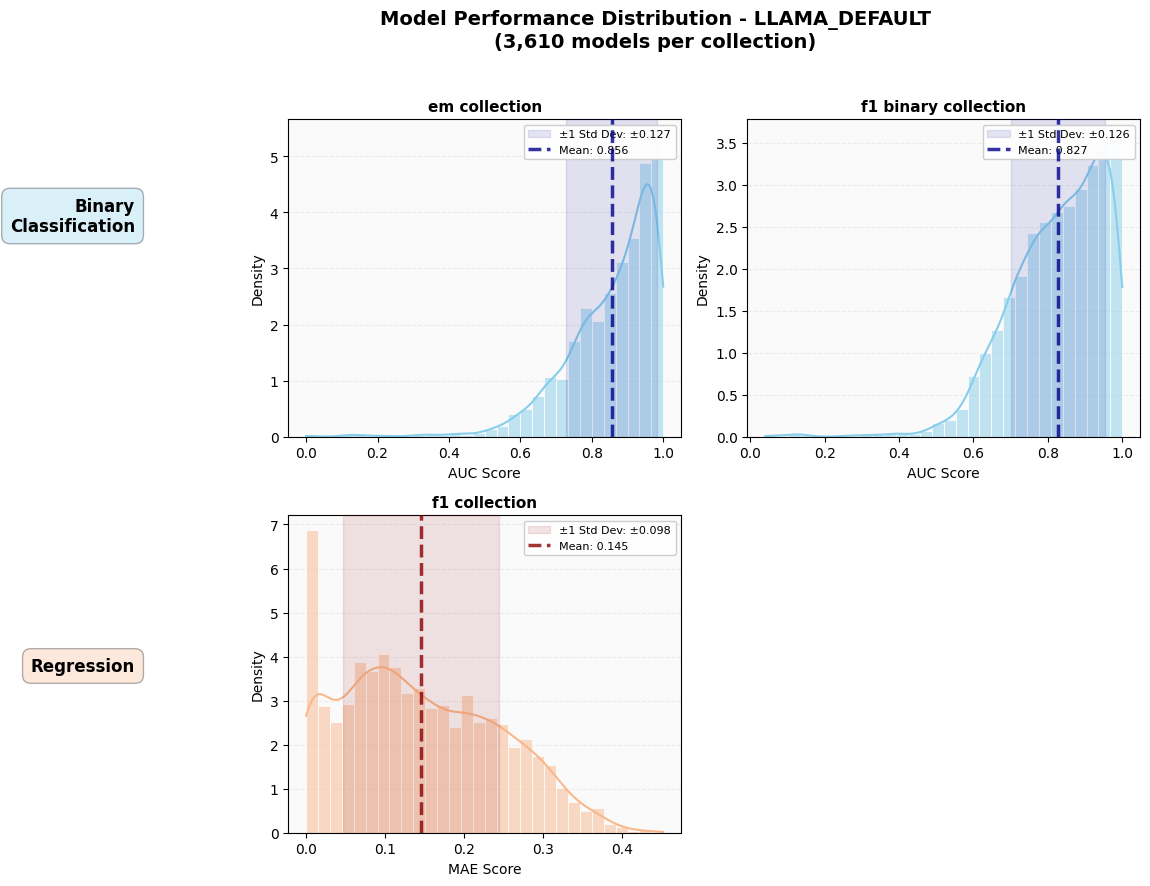


Completed processing llama_default


In [8]:
folder_name = "llama_default"
processed_collections_path = BASE_PATH / "processed_collections" / folder_name

# # Load collections
collections_data_llama_default = load_collections_for_folder(folder_name, BASE_PATH)

# Train models
if collections_data_llama_default:
    trained_models_llama_default = train_all_collections_in_folder(folder_name, collections_data_llama_default,  num_models=3610)
    
    # Save weights
    print(f"\n{'='*60}\nSaving weights for {folder_name}\n{'='*60}")
    saved_weights_llama_default = save_all_weights_for_folder(folder_name, trained_models_llama_default, BASE_PATH)
    
    # Generate evaluation summaries
    summaries_llama_default = create_summaries_for_folder(folder_name, trained_models_llama_default)
    
    # Store results
    all_results_by_folder[folder_name] = {
        "collections_data": collections_data_llama_default,
        "trained_models": trained_models_llama_default,
        "saved_weights": saved_weights_llama_default,
        "summaries": summaries_llama_default
    }
    
    # Visualize
    plot_folder_performance(folder_name, trained_models_llama_default)
    print(f"\nCompleted processing {folder_name}")
    gc.collect()
else:
    print(f"Failed to load collections for {folder_name}")

del collections_data_llama_default, trained_models_llama_default, saved_weights_llama_default, summaries_llama_default

## Processing: QWEN

Load, train, save, and visualize results for the qwen collection folder.


Loading collections from: qwen

Loading em_collection...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


  Train shape: (7220000, 4), Test shape: (722000, 4)

Loading f1_binary_collection...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


  Train shape: (6220000, 4), Test shape: (722000, 4)

Loading rougel_binary_collection...

Loading f1_collection...


...

  Total errors: 915/3610

Training 3610 models for f1_binary_collection (Binary)


Training f1_binary_collection: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3610/3610 [01:21<00:00, 44.08it/s]


  Total errors: 423/3610
Collection rougel_binary_collection not loaded

Training 3610 models for f1_collection (Regression)


Training f1_collection: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3610/3610 [01:23<00:00, 43.45it/s]


  Total errors: 0/3610
Collection rougel_collection not loaded

Saving weights for qwen

  Saving em_collection: weights torch.Size([3610, 100]), bias torch.Size([3610])
    Saved to: weights/qwen/em_collection
    Saved to: runs/qwen/datamodels/models/em_collection

  Saving f1_binary_collection: weights torch.Size([3610, 100]), bias torch.Size([3610])
    Saved to: weights/qwen/f1_binary_collection
    Saved to: runs/qwen/datamodels/models/f1_binary_collection

  Saving f1_collection: weights torch.Size([3610, 100]), bias torch.Size([3610])
    Saved to: weights/qwen/f1_collection
    Saved to: runs/qwen/datamodels/models/f1_collection

Evaluation Summary for qwen

em_collection:
  num_models: 3610
  successful_models: 1158
  mean_score: 0.8401
  std_score: 0.1459
  min_score: 0.0050
  max_score: 1.0000

f1_binary_collection:
  num_models: 3610
  successful_models: 2915
  mean_score: 0.8249
  std_score: 0.1562
  min_score: 0.0151
  max_score: 1.0000

f1_collection:
  num_models: 3610

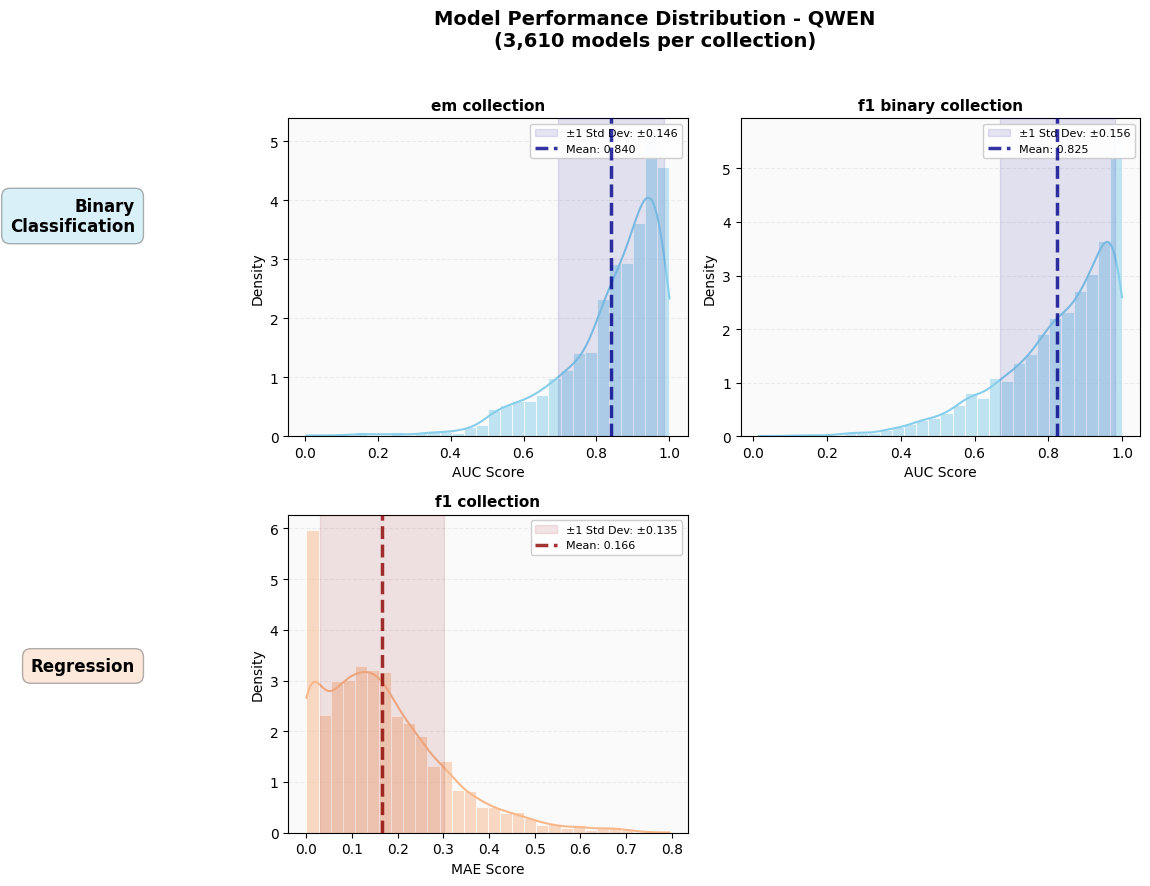


Completed processing qwen


In [7]:
folder_name = "qwen"

# Load collections
collections_data_qwen = load_collections_for_folder(folder_name, BASE_PATH)

# Train models
if collections_data_qwen:
    trained_models_qwen = train_all_collections_in_folder(folder_name, collections_data_qwen, num_models=3610)
    
    # Save weights
    print(f"\n{'='*60}\nSaving weights for {folder_name}\n{'='*60}")
    saved_weights_qwen = save_all_weights_for_folder(folder_name, trained_models_qwen, BASE_PATH)
    
    # Generate evaluation summaries
    summaries_qwen = create_summaries_for_folder(folder_name, trained_models_qwen)
    
    # Store results
    all_results_by_folder[folder_name] = {
        "collections_data": collections_data_qwen,
        "trained_models": trained_models_qwen,
        "saved_weights": saved_weights_qwen,
        "summaries": summaries_qwen
    }
    
    # Visualize
    plot_folder_performance(folder_name, trained_models_qwen)
    print(f"\nCompleted processing {folder_name}")
    gc.collect()
else:
    print(f"Failed to load collections for {folder_name}")

del collections_data_qwen, trained_models_qwen, saved_weights_qwen, summaries_qwen

## Processing: QWEN_DEFAULT

Load, train, save, and visualize results for the qwen_default collection folder.


Loading collections from: qwen_default

Loading em_collection...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


  Train shape: (7220000, 4), Test shape: (722000, 4)

Loading f1_binary_collection...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


  Train shape: (6220000, 4), Test shape: (722000, 4)

Loading rougel_binary_collection...

Loading f1_collection...


...

  Total errors: 2152/3610

Training 3610 models for f1_binary_collection (Binary)


Training f1_binary_collection: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3610/3610 [01:40<00:00, 36.02it/s]


  Total errors: 387/3610
Collection rougel_binary_collection not loaded

Training 3610 models for f1_collection (Regression)


Training f1_collection: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3610/3610 [01:39<00:00, 36.19it/s]


  Total errors: 0/3610
Collection rougel_collection not loaded

Saving weights for qwen_default

  Saving em_collection: weights torch.Size([3610, 100]), bias torch.Size([3610])
    Saved to: weights/qwen_default/em_collection
    Saved to: runs/qwen_default/datamodels/models/em_collection

  Saving f1_binary_collection: weights torch.Size([3610, 100]), bias torch.Size([3610])
    Saved to: weights/qwen_default/f1_binary_collection
    Saved to: runs/qwen_default/datamodels/models/f1_binary_collection

  Saving f1_collection: weights torch.Size([3610, 100]), bias torch.Size([3610])
    Saved to: weights/qwen_default/f1_collection
    Saved to: runs/qwen_default/datamodels/models/f1_collection

Evaluation Summary for qwen_default

em_collection:
  num_models: 3610
  successful_models: 1145
  mean_score: 0.8944
  std_score: 0.0985
  min_score: 0.2613
  max_score: 1.0000

f1_binary_collection:
  num_models: 3610
  successful_models: 3021
  mean_score: 0.8859
  std_score: 0.1090
  min_scor

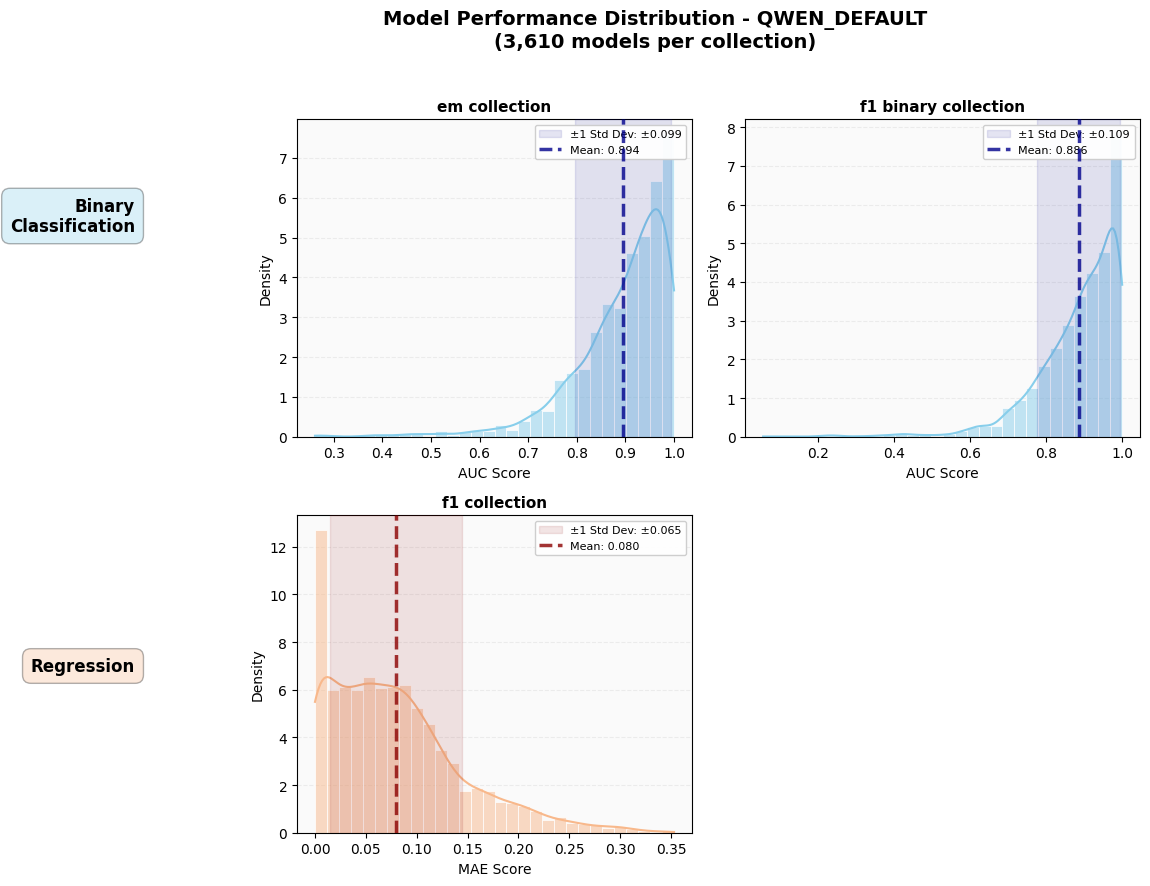


Completed processing qwen_default

COMPLETED: Processed 1 folders


In [9]:
folder_name = "qwen_default"

# Load collections
collections_data_qwen_default = load_collections_for_folder(folder_name, BASE_PATH)

# Train models
if collections_data_qwen_default:
    trained_models_qwen_default = train_all_collections_in_folder(folder_name, collections_data_qwen_default, num_models=3610)
    
    # Save weights
    print(f"\n{'='*60}\nSaving weights for {folder_name}\n{'='*60}")
    saved_weights_qwen_default = save_all_weights_for_folder(folder_name, trained_models_qwen_default, BASE_PATH)
    
    # Generate evaluation summaries
    summaries_qwen_default = create_summaries_for_folder(folder_name, trained_models_qwen_default)
    
    # Store results
    all_results_by_folder[folder_name] = {
        "collections_data": collections_data_qwen_default,
        "trained_models": trained_models_qwen_default,
        "saved_weights": saved_weights_qwen_default,
        "summaries": summaries_qwen_default
    }
    
    # Visualize
    plot_folder_performance(folder_name, trained_models_qwen_default)
    print(f"\nCompleted processing {folder_name}")
    gc.collect()
else:
    print(f"Failed to load collections for {folder_name}")

print(f"\n{'='*70}\nCOMPLETED: Processed {len(all_results_by_folder)} folders\n{'='*70}")
del collections_data_qwen, trained_models_qwen, saved_weights_qwen, summaries_qwen

## Cross-Folder Comparison

Compare model performance metrics across all three collection folders.

In [ ]:
# ============ CROSS-FOLDER COMPARISON: Mean Scores ============

# Collect all summary statistics
all_summaries_combined = []
for folder_name in COLLECTION_FOLDERS:
    if folder_name in all_results_by_folder:
        all_summaries_combined.extend(all_results_by_folder[folder_name]["summaries"])

if all_summaries_combined:
    summary_df = pl.DataFrame(all_summaries_combined)
    
    print("\n" + "="*100)
    print("COMPREHENSIVE SUMMARY: All Folders and Collections")
    print("="*100)
    print(summary_df)
    
    # ============ Comparison Plot 1: Mean Scores by Collection (Across Folders) ============
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Binary collections comparison
    binary_summary = summary_df.filter(pl.col("type") == "Binary Classification")
    if len(binary_summary) > 0:
        binary_pivot = binary_summary.select(["folder", "collection", "mean_score"]).to_pandas()
        binary_pivot_wide = binary_pivot.pivot(index="collection", columns="folder", values="mean_score")
        
        binary_pivot_wide.plot(kind="bar", ax=axes[0], width=0.8, 
                               color=["#1f77b4", "#ff7f0e", "#2ca02c"])
        axes[0].set_title("AUC Scores - Binary Collections", fontsize=12, fontweight='bold')
        axes[0].set_xlabel("Collection", fontsize=11)
        axes[0].set_ylabel("Mean AUC Score", fontsize=11)
        axes[0].legend(title="Folder", fontsize=10, title_fontsize=10)
        axes[0].grid(axis='y', alpha=0.3, linestyle='--')
        axes[0].set_axisbelow(True)
        axes[0].set_facecolor('#fafafa')
        axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
    
    # Regression collections comparison
    regression_summary = summary_df.filter(pl.col("type") == "Regression")
    if len(regression_summary) > 0:
        regression_pivot = regression_summary.select(["folder", "collection", "mean_score"]).to_pandas()
        regression_pivot_wide = regression_pivot.pivot(index="collection", columns="folder", values="mean_score")
        
        regression_pivot_wide.plot(kind="bar", ax=axes[1], width=0.8,
                                   color=["#1f77b4", "#ff7f0e", "#2ca02c"])
        axes[1].set_title("MAE Scores - Regression Collections", fontsize=12, fontweight='bold')
        axes[1].set_xlabel("Collection", fontsize=11)
        axes[1].set_ylabel("Mean MAE Score", fontsize=11)
        axes[1].legend(title="Folder", fontsize=10, title_fontsize=10)
        axes[1].grid(axis='y', alpha=0.3, linestyle='--')
        axes[1].set_axisbelow(True)
        axes[1].set_facecolor('#fafafa')
        axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
    
    fig.suptitle('Cross-Folder Comparison: Mean Performance Metrics', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    plt.close()
    
    # ============ Comparison Plot 2: Heatmap of Mean Scores ============
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    # Binary collections heatmap
    if len(binary_summary) > 0:
        binary_heatmap = binary_summary.select(["folder", "collection", "mean_score"]).to_pandas()
        binary_heatmap_wide = binary_heatmap.pivot(index="collection", columns="folder", values="mean_score")
        
        sns.heatmap(binary_heatmap_wide, annot=True, fmt=".4f", cmap="RdYlGn", 
                   ax=axes[0], cbar_kws={"label": "Mean AUC"}, vmin=0, vmax=1)
        axes[0].set_title("AUC Scores - Binary Collections", fontsize=12, fontweight='bold')
    
    # Regression collections heatmap
    if len(regression_summary) > 0:
        regression_heatmap = regression_summary.select(["folder", "collection", "mean_score"]).to_pandas()
        regression_heatmap_wide = regression_heatmap.pivot(index="collection", columns="folder", values="mean_score")
        
        sns.heatmap(regression_heatmap_wide, annot=True, fmt=".4f", cmap="RdYlGn_r",
                   ax=axes[1], cbar_kws={"label": "Mean MAE"})
        axes[1].set_title("MAE Scores - Regression Collections", fontsize=12, fontweight='bold')
    
    fig.suptitle('Cross-Folder Performance Heatmap', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    plt.close()
    
    # ============ Summary Statistics Table ============
    print("\n" + "="*100)
    print("SUMMARY STATISTICS BY FOLDER AND TYPE")
    print("="*100)
    
    folder_type_stats = summary_df.group_by(["folder", "type"]).agg([
        pl.col("mean_score").mean().alias("avg_mean_score"),
        pl.col("mean_score").min().alias("min_mean_score"),
        pl.col("mean_score").max().alias("max_mean_score"),
        pl.col("std_score").mean().alias("avg_std_score"),
        pl.col("successful_models").mean().alias("avg_successful_models"),
    ])
    
    print(folder_type_stats)
else:
    print("No results to compare - ensure models have been trained for all folders")